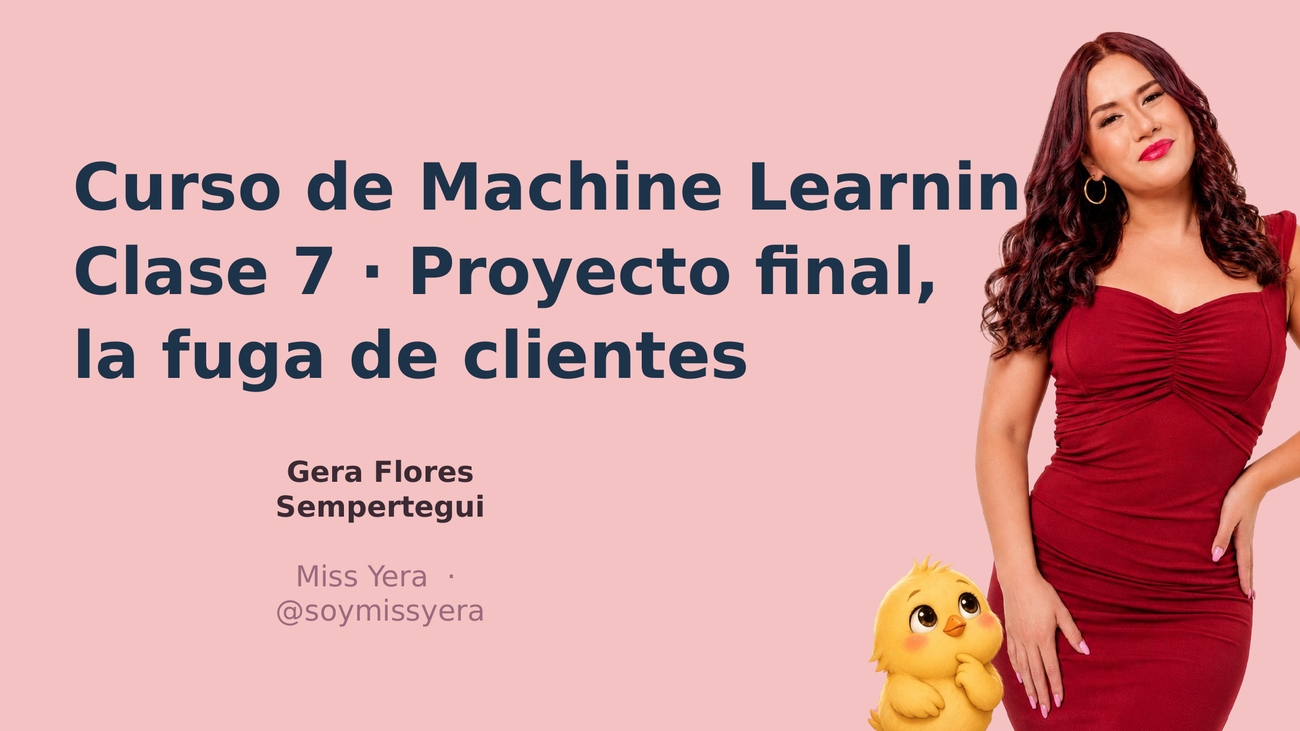
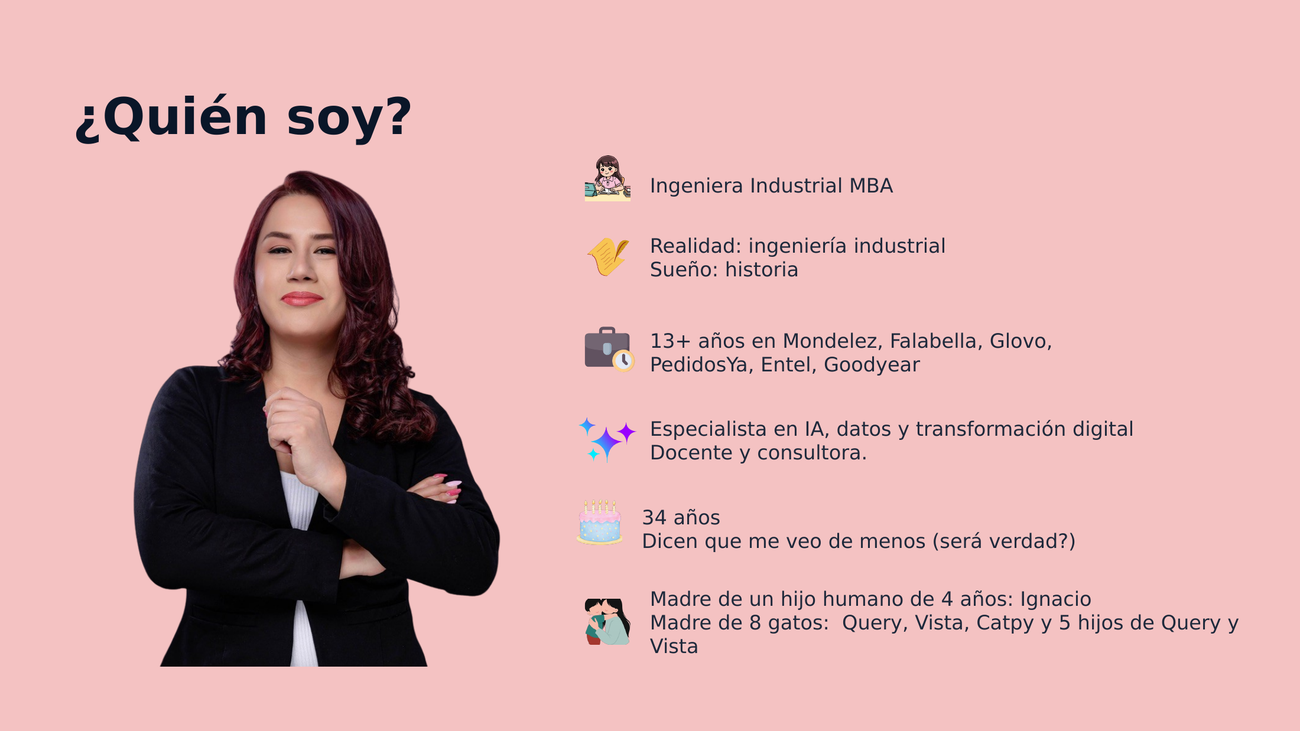
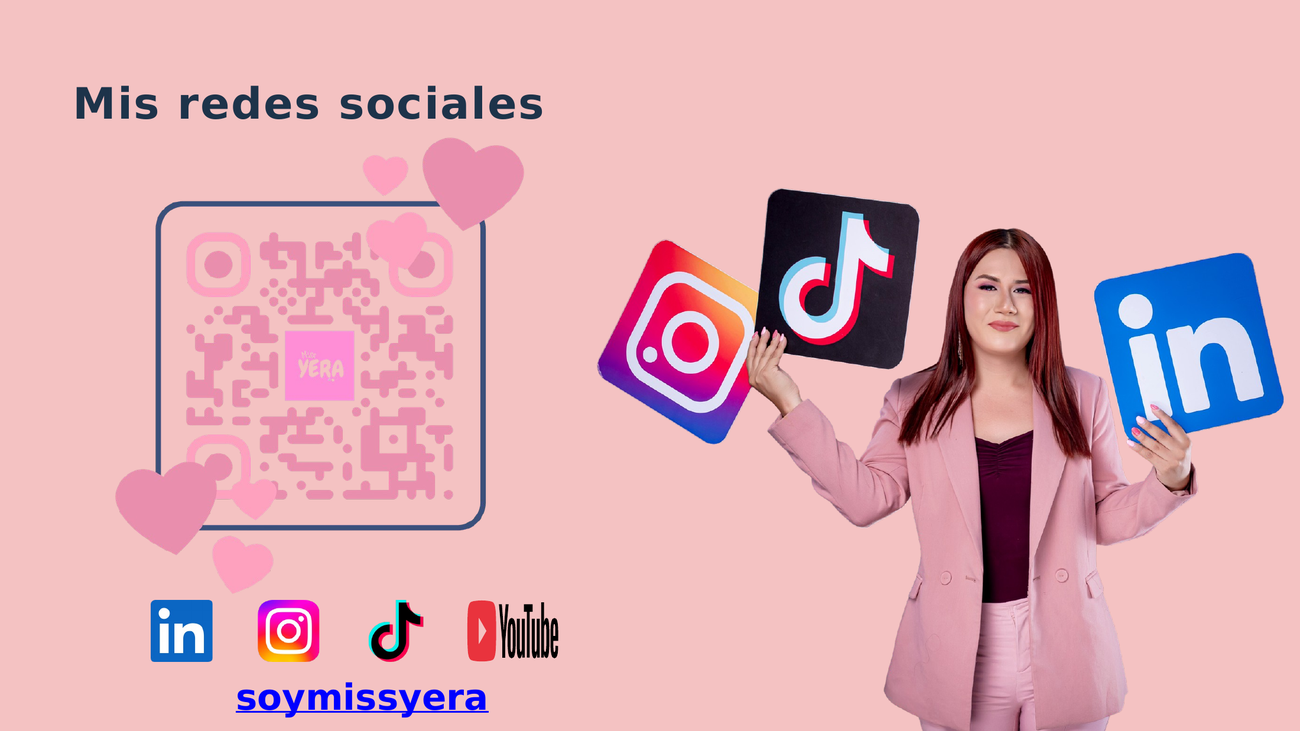


<div style="background:#FFF5F8;border:2px solid #E0218A;padding:14px 18px;border-radius:12px;"><b style="color:#1B2A5B;">Regla de oro del curso,</b> nadie ejecuta una celda sin predecir en voz alta qué va a pasar. Y desde ya, con la Miss se aprende haciendo. 🐥</div>


## 🧭 ¿Dónde estamos en el curso?

Progreso, 🐥🐥🐥🐥🐥🐥🐥 · clase 7 de 7

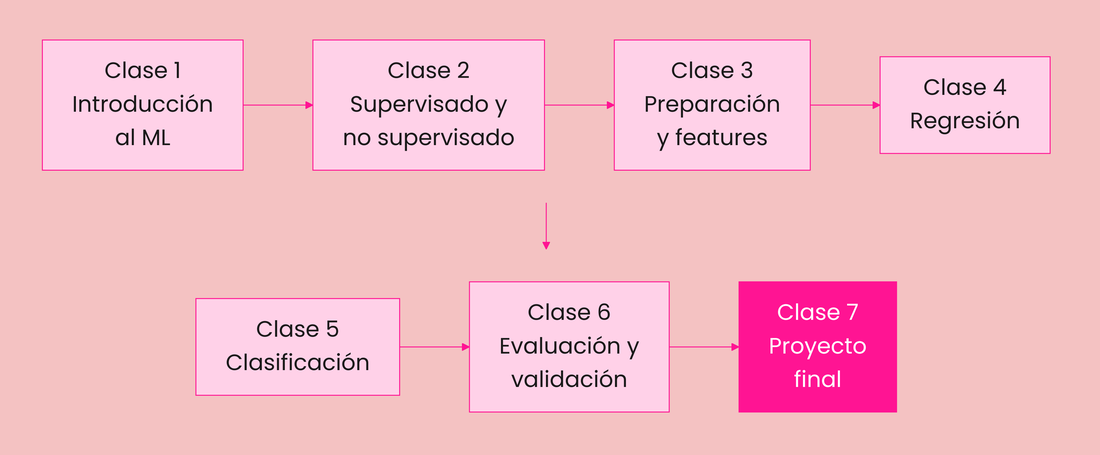


## 🔁 Antes de arrancar, 60 segundos de la clase anterior

En la clase 6, overfitting en vivo, la auditoría del regulador, dejamos lista la base para lo de hoy. Si algo de lo que sigue no te suena, regresa a ese notebook o al video de la clase 6 de la playlist antes de continuar.


In [1]:
#@title 🎬 Toca play · Quiz de entrada, ¿qué te llevaste de la clase anterior?
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de entrada, ¿qué te llevaste de la clase anterior?</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. ¿Cómo se ve el overfitting en los números?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin7_0" value="0"> Nota baja en train y alta en test</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin7_0" value="1"> Nota altísima en train y caída fuerte en test</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin7_0" value="2"> Notas iguales en todos lados</label><div id="qin7_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Cuántas veces se toca el test en el protocolo profesional?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin7_1" value="0"> Cada vez que pruebo un modelo</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin7_1" value="1"> Una sola vez, al final</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin7_1" value="2"> Nunca</label><div id="qin7_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "el memori\u00f3n brilla en su cuaderno y se congela en el examen"], [1, "el test es el examen final bajo llave"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qin7_"+i+"\']:checked");
        var fb=document.getElementById("qin7_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🎯 Lo que vas a lograr hoy

- Arrancar por la arquitectura y la gobernanza, data contract antes que cualquier modelo.
- Recorrer el pipeline completo sin fuga de información, del EDA interrogatorio al torneo con baseline.
- Cerrar como se cierra en la vida real, umbral por costos, explicabilidad, equidad y decisión de negocio.


## 📩 El pedido de la semana en PolliCreditos

<div style="background:#FFF5F8;border:2px solid #E0218A;padding:14px 18px;border-radius:12px;"><i>"Los buenos clientes se nos están yendo a la competencia. Quiero el proyecto completo, con costos, explicaciones y equidad, listo para presentar al directorio."</i><br><b style="color:#1B2A5B;">El CEO de PolliCreditos 🐥</b></div>


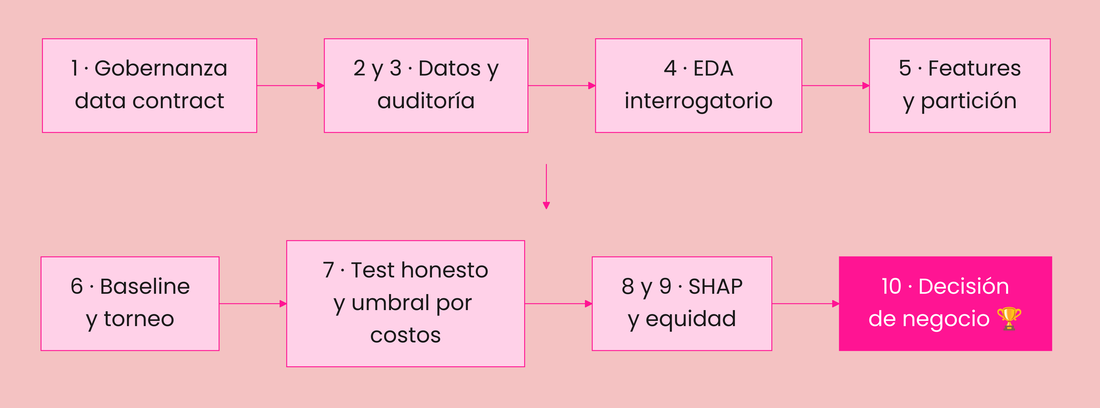

*El mapa del proyecto completo, hoy recorres las diez fases como una senior.*


### 🗣️ El vocabulario de hoy, en cristiano y en inglés

| En este curso | En inglés (lo verás en todos lados) | Qué es |
|---|---|---|
| Contrato de datos | **data contract** | qué tipo, origen, dueño y calidad se espera de cada columna, firmado antes de modelar |
| Línea base | **baseline** | el modelo tonto de referencia, la vara mínima del torneo |
| Tubería | **pipeline** | preprocesamiento y modelo empaquetados juntos, sin fuga posible |
| Explicabilidad | **SHAP** | abrir la caja y ver qué variable empujó cada predicción |
| Equidad | **fairness** | verificar que el modelo no castigue sistemáticamente a un grupo |
| Deriva | **drift** | cuando el mundo cambia y el modelo se va quedando viejo |



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">📱 El caso de hoy</b><br>
Trabajamos para <b>PolliCreditos</b>, nuestra fintech de microcréditos en Perú. Cada mes se le fugan clientes a la competencia y adquirir un cliente nuevo cuesta unas cinco veces más que retener uno. El área comercial nos pide un modelo que identifique qué clientes tienen alta probabilidad de irse el próximo mes, para llamarlos antes con una oferta de retención. Este es el clásico problema de <b>churn</b> y es de los proyectos más pedidos en la vida real.
</div>


## 1. Arquitectura y gobernanza, lo primero no es el modelo

Un proyecto serio de ML empieza en papel. Antes de escribir una sola línea de pandas definimos qué vamos a predecir, con qué datos, con qué métrica de éxito y qué riesgos existen. Esto separa a una data scientist senior de alguien que solo entrena modelos.

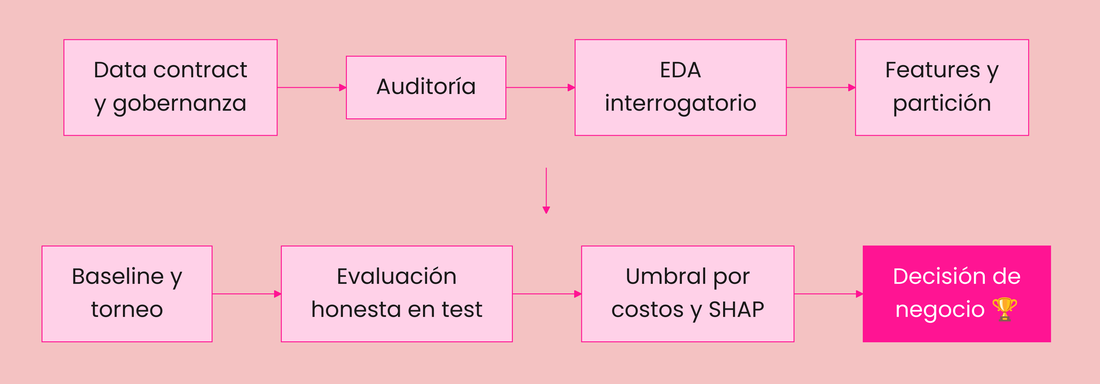

*El proyecto entero es una sola cadena, de la gobernanza de los datos a la decisión de negocio.*



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🏗️ Definición del problema</b><br>
<b>Pregunta de negocio,</b> ¿qué clientes van a cancelar su tipo_credito el próximo mes?<br><b>Tipo de problema,</b> clasificación binaria supervisada, target <code>fuga</code> con valores 0 y 1.<br><b>Unidad de análisis,</b> un cliente activo al cierre de mes.<br><b>Métrica principal,</b> recall de la clase fuga, porque perder a un cliente que se iba a ir cuesta más que llamar de más. Métrica de control, precision, para no quemar al call center.<br><b>Criterio de éxito,</b> superar al baseline y lograr un recall de fuga por encima de 0.70 con precision razonable.
</div>



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">📜 Data contract del dataset</b><br>
Acordamos con el equipo de datos qué debe cumplir cada columna antes de entrar al modelo:<br><br><ul><li><code>id_cliente</code>, texto único, jamás entra como feature</li><li><code>meses_antiguedad</code>, entero entre 0 y 120</li><li><code>tipo_credito</code>, categórica con valores individual, negocio, corporativo</li><li><code>cuota_mensual</code>, soles, positivo, tope razonable 500</li><li><code>creditos_activos</code>, numérico positivo</li><li><code>reclamos</code>, entero entre 0 y 30</li><li><code>pago_puntual_pct</code>, porcentaje entre 0 y 100</li><li><code>oferta_competencia</code>, binaria 0 o 1</li><li><code>distrito</code>, categórica, solo se usa agregada por zona</li><li><code>fuga</code>, target binaria 0 o 1</li></ul>Todo lo que viole el contrato se reporta, se corrige o se elimina con justificación escrita.
</div>



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">⚠️ Riesgos y sesgos identificados</b><br>
<ul><li><b>Sesgo geográfico,</b> si el modelo aprende que ciertos distritos fugan más, podríamos terminar dando peores ofertas a zonas de menores ingresos. Vamos a vigilar el desempeño por zona.</li><li><b>Fuga de información temporal,</b> ninguna feature puede contener información posterior a la fecha de corte, por ejemplo el motivo de cancelación.</li><li><b>Clases desbalanceadas,</b> la fuga mensual es minoritaria, así que accuracy sola nos mentiría.</li></ul>
</div>


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta oficial Miss Yera para todos los gráficos de la clase
YERA = ['#FF1493', '#FF69B4', '#FFB6C1', '#00C9A7', '#FFC75F', '#1B2A5B']
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.prop_cycle': plt.cycler(color=['#FF1493', '#00C9A7', '#1B2A5B', '#FFC75F', '#FF69B4']),
})
np.random.seed(42)  # semilla fija, reproducible o no existe
print('Setup listo, pollito 🐥')

Setup listo, pollito 🐥


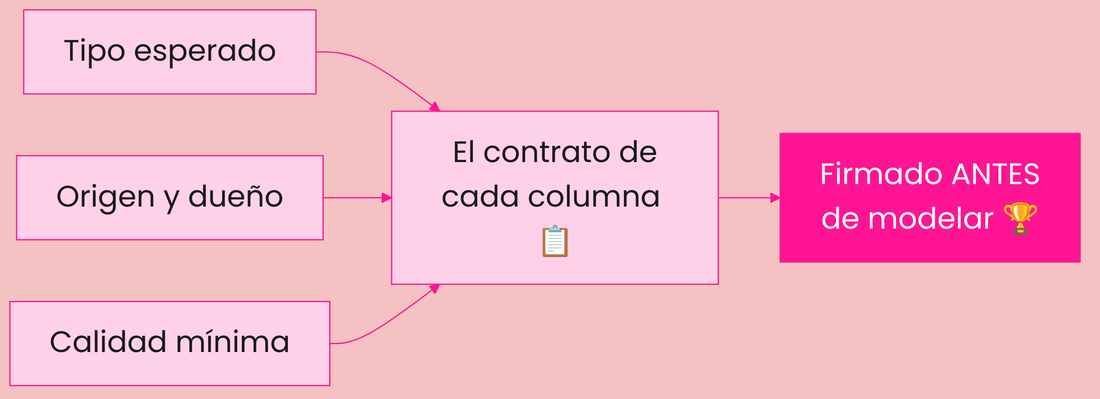

*El contrato se firma antes de tocar un solo modelo, así trabaja una senior.*


### 🔥 Calentamiento antes de avanzar, tú ya firmas contratos de datos

Antes de un viaje revisas tu checklist, pasaporte vigente, tarjeta que funcione, reserva confirmada. Si algo no cumple, no viajas. El data contract es ese checklist pero para columnas.


<div style="background:#FFF5F8;border:2px solid #1B2A5B;padding:14px 18px;border-radius:12px;">🔮 <b>Predice antes de ejecutar,</b> esta celda va a el checklist del viaje, versión data contract. ¿Qué crees que saldrá?</div>


In [3]:
# El checklist del viaje, versión data contract
contrato = {"pasaporte": "vigente", "tarjeta": "activa", "reserva": "confirmada"}
mi_situacion = {"pasaporte": "vigente", "tarjeta": "bloqueada", "reserva": "confirmada"}

for item, esperado in contrato.items():
    real = mi_situacion[item]
    estado = "✅" if real == esperado else f"🚨 esperaba {esperado} y encontré {real}"
    print(f"{item:>10} → {estado}")
print("\nCon una sola cláusula rota, el viaje se detiene. Con los datos, igual.")

 pasaporte → ✅
   tarjeta → 🚨 esperaba activa y encontré bloqueada
   reserva → ✅

Con una sola cláusula rota, el viaje se detiene. Con los datos, igual.


## 2. Los datos

En la vida real este dataset saldría de la base de la fintech. Aquí lo generamos sintético con semilla fija y con la suciedad típica de un extracto real, porque limpiar también es parte del proyecto.

In [4]:
import pandas as pd

np.random.seed(42)
n = 1400

tipo_credito = np.random.choice(['individual', 'negocio', 'corporativo'], n, p=[0.45, 0.42, 0.13])
meses = np.random.randint(1, 96, n)
cuota = np.round(np.where(tipo_credito == 'individual', np.random.normal(35, 9, n),
        np.where(tipo_credito == 'negocio', np.random.normal(75, 18, n),
                 np.random.normal(140, 30, n))).clip(10, 320), 2)
gb = np.round(np.random.gamma(3.0, 4.5, n), 1)
reclamos = np.random.poisson(1.6, n)
pago = np.round(np.clip(np.random.normal(88, 12, n), 20, 100), 1)
portab = np.random.binomial(1, 0.22, n)
zona = np.random.choice(['Lima Norte', 'Lima Centro', 'Lima Sur', 'Lima Este', 'Callao'], n)

# Señal de fuga calibrada, ni obvia ni imposible
logit = (-1.7
         + 1.00 * reclamos
         - 0.065 * meses
         - 0.12 * (pago - 85)
         + 2.0 * portab
         + 1.1 * (tipo_credito == 'individual').astype(int)
         + np.random.normal(0, 0.45, n))
p_fuga = 1 / (1 + np.exp(-logit))
fuga = np.random.binomial(1, p_fuga)

df = pd.DataFrame({
    'id_cliente': [f'KM{100000 + i}' for i in range(n)],
    'tipo_credito': tipo_credito, 'meses_antiguedad': meses, 'cuota_mensual': cuota,
    'creditos_activos': gb, 'reclamos': reclamos,
    'pago_puntual_pct': pago, 'oferta_competencia': portab,
    'zona': zona, 'fuga': fuga,
})

# Suciedad pedagógica, como llega la data de verdad
idx = np.random.choice(n, 40, replace=False)
df.loc[idx[:18], 'creditos_activos'] = np.nan
df.loc[idx[18:30], 'pago_puntual_pct'] = np.nan
df.loc[idx[30:36], 'tipo_credito'] = 'Individual'          # misma categoría, otra mayúscula
df.loc[idx[36:40], 'meses_antiguedad'] = -1     # viola el data contract
df = pd.concat([df, df.sample(12, random_state=42)], ignore_index=True)  # duplicados

print(df.shape)
df.head()

(1412, 10)


,id_cliente,tipo_credito,meses_antiguedad,cuota_mensual,creditos_activos,reclamos,pago_puntual_pct,oferta_competencia,zona,fuga
0,KM100000,individual,64,33.82,13.9,2,88.2,0,Callao,0
1,KM100001,corporativo,84,191.79,15.2,1,100.0,0,Lima Norte,0
2,KM100002,negocio,28,99.67,9.8,3,79.2,0,Callao,1
3,KM100003,negocio,37,87.51,12.9,0,72.7,0,Callao,0
4,KM100004,individual,47,36.52,2.6,1,74.2,0,Lima Centro,0



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués de esta celda</b><br>
La señal de fuga la construimos con un logit que combina reclamos, antigüedad, puntualidad de pago, oferta de la competencia y tipo de tipo_credito más ruido. Ese ruido es clave, sin él cualquier modelo sacaría 100 por ciento y eso en la vida real es sinónimo de fuga de información, no de talento. Los nulos, duplicados, mayúsculas inconsistentes y el valor imposible de antigüedad son exactamente lo que te vas a encontrar en una base real.
</div>


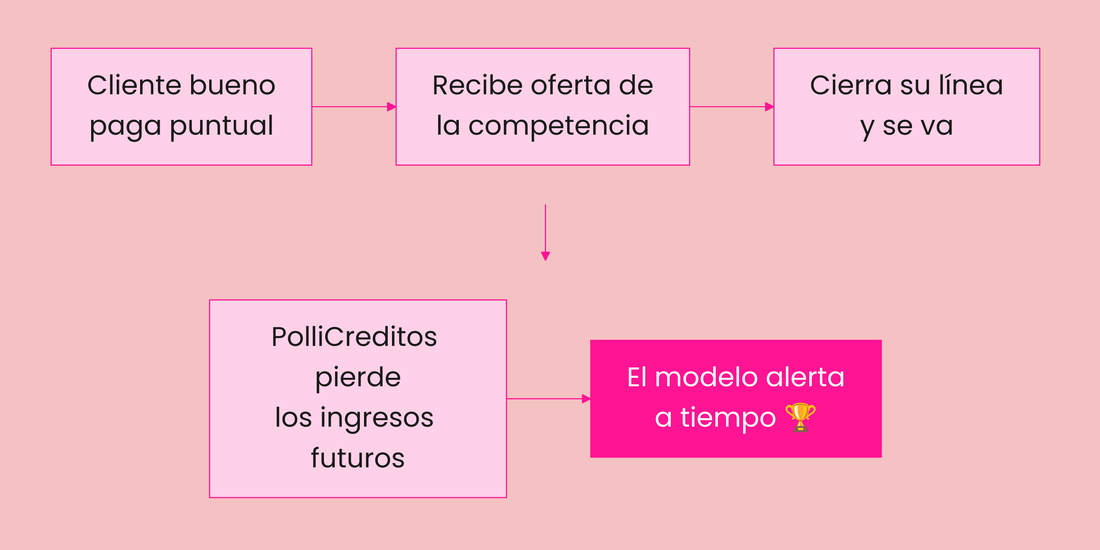

*La historia completa de la fuga, y el punto exacto donde el modelo cambia el final.*


## 3. Auditoría contra el data contract

Antes del EDA verificamos qué reglas del contrato se violan y lo dejamos por escrito.

In [5]:
print('Duplicados por id,', df.duplicated(subset='id_cliente').sum())
print('Nulos por columna')
print(df.isna().sum()[df.isna().sum() > 0])
print()
print('Valores de tipo_credito,', sorted(df['tipo_credito'].unique()))
print('Antigüedad fuera de rango,', (df['meses_antiguedad'] < 0).sum())

Duplicados por id, 12
Nulos por columna
creditos_activos    19
pago_puntual_pct    12
dtype: int64

Valores de tipo_credito, ['Individual', 'corporativo', 'individual', 'negocio']
Antigüedad fuera de rango, 4


<div style="background:#FFF5F8;border:2px solid #1B2A5B;padding:14px 18px;border-radius:12px;">🔮 <b>Predice antes de ejecutar,</b> esta celda va a correcciones con justificación. ¿Qué crees que saldrá?</div>


In [6]:
# Correcciones con justificación
df = df.drop_duplicates(subset='id_cliente', keep='first').copy()   # duplicado exacto, error de extracción
df['tipo_credito'] = df['tipo_credito'].str.lower()                                  # normalizamos categorías
df = df[df['meses_antiguedad'] >= 0].copy()                          # viola el contrato, sin fecha de alta confiable

# Los nulos NO los imputamos aquí, eso lo hará el pipeline solo con datos de train
print('Filas después de la limpieza estructural,', len(df))
print('Tasa de fuga,', round(df['fuga'].mean(), 3))

Filas después de la limpieza estructural, 1396
Tasa de fuga, 0.229



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🚫 ¿Por qué no imputamos los nulos todavía?</b><br>
Si rellenamos los nulos con la mediana de todo el dataset, la mediana ya vio los datos de test. Eso es fuga de información, sutil pero real. La imputación va dentro del pipeline, que aprende sus parámetros solo del train. Regla de oro, <b>fit solo en train, transform en ambos</b>.
</div>


## 4. EDA, interrogatorio a los datos

Un EDA no es imprimir gráficos bonitos, es hacerle preguntas incómodas al dataset y anotar las respuestas.

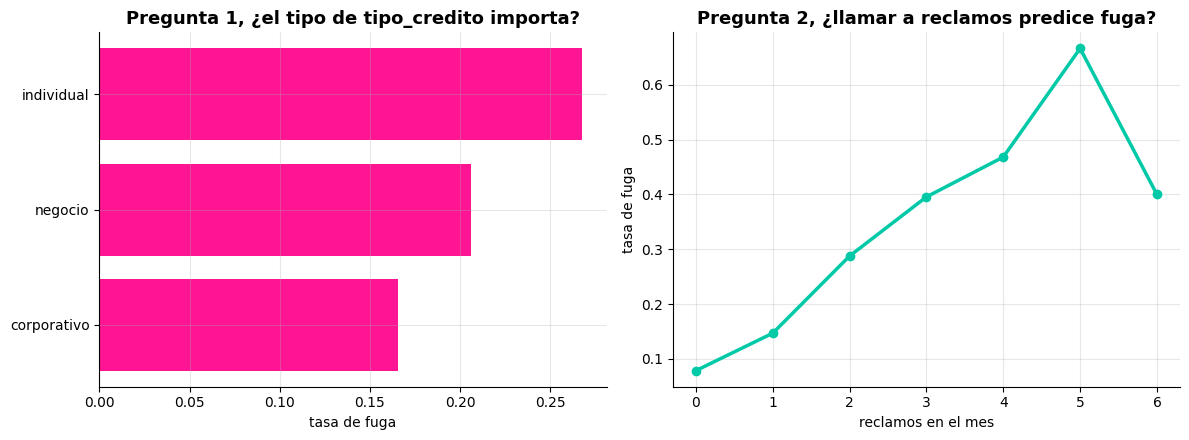

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

tasa_plan = df.groupby('tipo_credito')['fuga'].mean().sort_values()
axes[0].barh(tasa_plan.index, tasa_plan.values, color=YERA[0])
axes[0].set_title('Pregunta 1, ¿el tipo de tipo_credito importa?')
axes[0].set_xlabel('tasa de fuga')

tasa_sop = df.groupby('reclamos')['fuga'].mean()
tasa_sop = tasa_sop[tasa_sop.index <= 6]
axes[1].plot(tasa_sop.index, tasa_sop.values, marker='o', color=YERA[3], linewidth=2.5)
axes[1].set_title('Pregunta 2, ¿llamar a reclamos predice fuga?')
axes[1].set_xlabel('reclamos en el mes')
axes[1].set_ylabel('tasa de fuga')

plt.tight_layout()
plt.show()

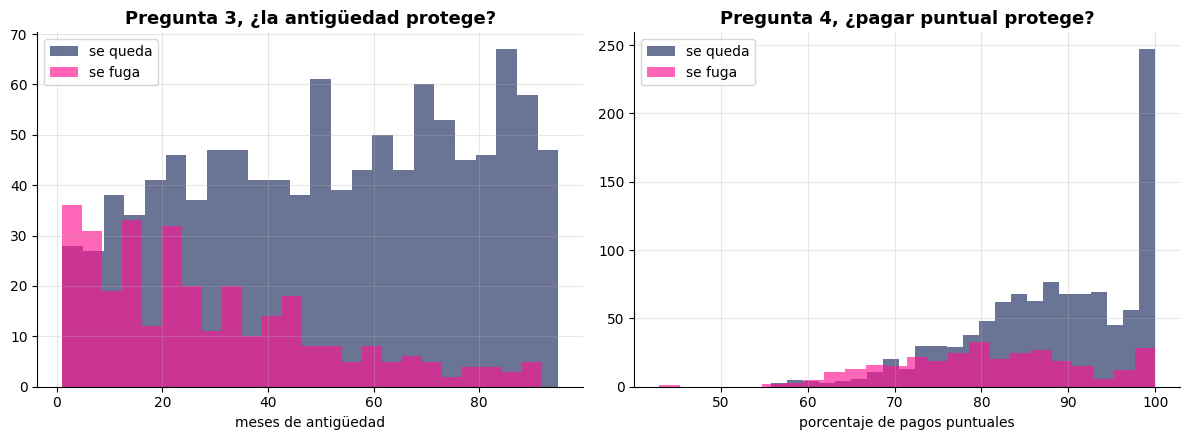

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for valor, color, etiqueta in [(0, YERA[5], 'se queda'), (1, YERA[0], 'se fuga')]:
    sub = df[df['fuga'] == valor]
    axes[0].hist(sub['meses_antiguedad'], bins=24, alpha=0.65, color=color, label=etiqueta)
    axes[1].hist(sub['pago_puntual_pct'].dropna(), bins=24, alpha=0.65, color=color, label=etiqueta)

axes[0].set_title('Pregunta 3, ¿la antigüedad protege?')
axes[0].set_xlabel('meses de antigüedad')
axes[0].legend()
axes[1].set_title('Pregunta 4, ¿pagar puntual protege?')
axes[1].set_xlabel('porcentaje de pagos puntuales')
axes[1].legend()
plt.tight_layout()
plt.show()

<div style="background:#FFF5F8;border:2px solid #1B2A5B;padding:14px 18px;border-radius:12px;">🔮 <b>Predice antes de ejecutar,</b> esta celda va a pregunta 5, ¿hay riesgo de sesgo geográfico?. ¿Qué crees que saldrá?</div>


In [9]:
# Pregunta 5, ¿hay riesgo de sesgo geográfico?
print(df.groupby('zona')['fuga'].agg(['mean', 'count']).round(3))

              mean  count
zona                     
Callao       0.223    309
Lima Centro  0.220    241
Lima Este    0.232    293
Lima Norte   0.224    277
Lima Sur     0.243    276



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🔎 Hallazgos del EDA</b><br>
<ul><li>El tipo_credito individual fuga más que el corporativo, tiene sentido, menos compromiso contractual.</li><li>Las reclamos son una señal fuerte, cada reclamo extra sube la tasa de fuga. El cliente que llama molesto tres veces te está avisando.</li><li>Los clientes antiguos y los pagadores puntuales fugan menos.</li><li>Las zonas tienen tasas parecidas, buen indicio de que el modelo no necesita apoyarse en la geografía. Igual la vigilamos al final.</li></ul>
</div>


## 5. Feature engineering y partición

Creamos una feature de negocio y separamos train y test de forma estratificada antes de cualquier transformación que aprenda de los datos.

In [10]:
from sklearn.model_selection import train_test_split

# Feature de negocio, cuota por crédito activo, cuánto paga el cliente por lo que usa
df['cuota_por_credito'] = (df['cuota_mensual'] / (df['creditos_activos'] + 1)).round(2)

numericas = ['meses_antiguedad', 'cuota_mensual', 'creditos_activos',
             'reclamos', 'pago_puntual_pct', 'cuota_por_credito']
categoricas = ['tipo_credito', 'zona']
binarias = ['oferta_competencia']

X = df[numericas + categoricas + binarias]
y = df['fuga']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

print('Train,', X_train.shape, '| tasa de fuga', round(y_train.mean(), 3))
print('Test, ', X_test.shape, '| tasa de fuga', round(y_test.mean(), 3))

Train, (1047, 9) | tasa de fuga 0.228
Test,  (349, 9) | tasa de fuga 0.229



<div style="background: #FFF5F8; border: 2px dashed #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#1B2A5B; font-size: 16px;">📖 Concepto nuevo, <span style="color:#FF1493;">ColumnTransformer</span></b><br>
Pieza de scikit-learn que aplica transformaciones distintas a columnas distintas dentro de un mismo pipeline, por ejemplo imputar y escalar las numéricas mientras codifica las categóricas.<br>
<i>🐥 En idioma pollito, es la cocina de un restaurante con estaciones, la parrilla trata la carne, la barra fría trata las ensaladas, y todo sale junto en un solo plato.</i>
</div>


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

prep = ColumnTransformer([
    ('num', Pipeline([
        ('imputar', SimpleImputer(strategy='median')),
        ('escalar', StandardScaler()),
    ]), numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
    ('bin', 'passthrough', binarias),
])

prep

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## 6. Baseline y torneo de modelos

Primero el baseline tonto. Si un modelo no le gana con claridad, no merece producción. Después seis modelos compiten con validación cruzada sobre el train.

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

modelos = {
    'Baseline (mayoría)': DummyClassifier(strategy='most_frequent'),
    'Regresión logística': LogisticRegression(max_iter=2000),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Árbol de decisión': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random forest': RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    'Gradient boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', prep), ('modelo', modelo)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    resultados[nombre] = scores
    print(f'{nombre:22s} F1 = {scores.mean():.3f} ± {scores.std():.3f}')

Baseline (mayoría)     F1 = 0.000 ± 0.000
Regresión logística    F1 = 0.668 ± 0.052
KNN                    F1 = 0.469 ± 0.056


Árbol de decisión      F1 = 0.553 ± 0.050


Random forest          F1 = 0.486 ± 0.065


Gradient boosting      F1 = 0.611 ± 0.051


SVM                    F1 = 0.592 ± 0.053


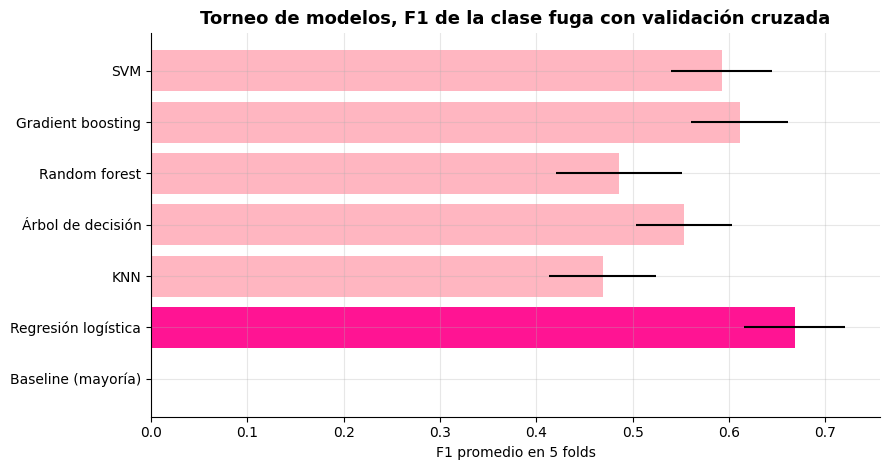

In [13]:
nombres = list(resultados.keys())
medias = [resultados[n].mean() for n in nombres]
stds = [resultados[n].std() for n in nombres]
colores = [YERA[0] if m == max(medias) else YERA[2] for m in medias]

plt.figure(figsize=(9, 4.8))
plt.barh(nombres, medias, xerr=stds, color=colores)
plt.title('Torneo de modelos, F1 de la clase fuga con validación cruzada')
plt.xlabel('F1 promedio en 5 folds')
plt.tight_layout()
plt.show()


<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Por qué F1 y no accuracy para el torneo?</b><br>
La fuga es minoritaria. Un modelo que dice que nadie se fuga tendría accuracy alta y valor cero para el negocio, por eso el baseline de mayoría es tan importante como referencia. F1 balancea precision y recall de la clase que nos importa, la fuga.
</div>


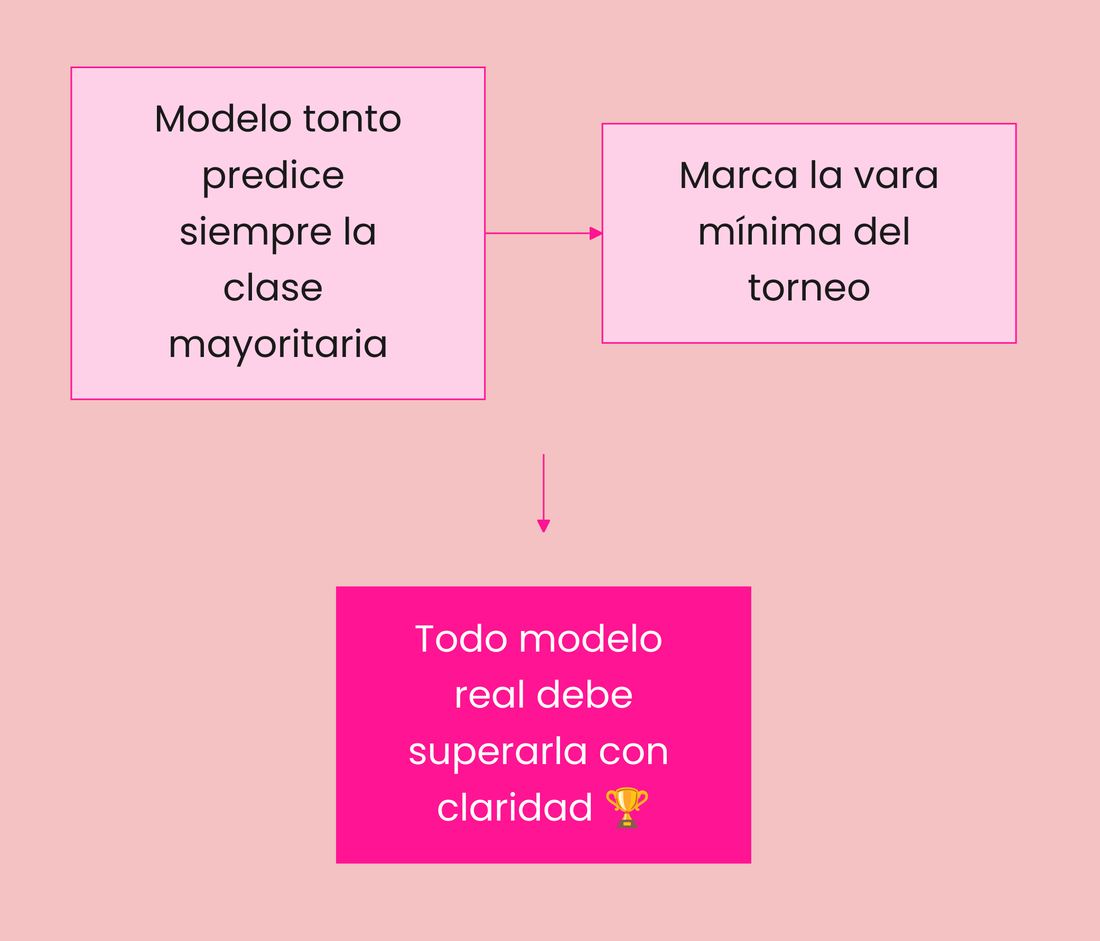

*Sin vara mínima no hay torneo serio, si no le ganas al modelo tonto, algo anda mal.*


### 🩻 Radiografía sencilla del código · la tubería sin fugas

| Pieza | Qué hace en palabras |
|---|---|
| `Pipeline([('prep', prep), ('modelo', ...)])` | empaqueta preprocesamiento y modelo, el escalador solo aprende del train, siempre |
| `pipe_final.fit(X_train, y_train)` | entrena TODO el paquete de un golpe, sin pasos sueltos que se olviden |
| `pipe_final.predict_proba(X_test)[:, 1]` | probabilidades de fuga en el examen, listas para la perilla del umbral |


## 7. Evaluación honesta del modelo elegido en test

Elegimos el mejor del torneo, lo entrenamos con todo el train y lo evaluamos una sola vez en test, datos que jamás vio.

In [14]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

mejor_nombre = max(resultados, key=lambda k: resultados[k].mean())
print('Modelo elegido,', mejor_nombre)

pipe_final = Pipeline([('prep', prep), ('modelo', modelos[mejor_nombre])])
pipe_final.fit(X_train, y_train)

y_pred = pipe_final.predict(X_test)
y_proba = pipe_final.predict_proba(X_test)[:, 1]

print()
print(classification_report(y_test, y_pred, target_names=['se queda', 'se fuga']))
print('ROC AUC,', round(roc_auc_score(y_test, y_proba), 3))

Modelo elegido, Regresión logística

              precision    recall  f1-score   support

    se queda       0.89      0.95      0.92       269
     se fuga       0.79      0.60      0.68        80

    accuracy                           0.87       349
   macro avg       0.84      0.78      0.80       349
weighted avg       0.87      0.87      0.86       349

ROC AUC, 0.889


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


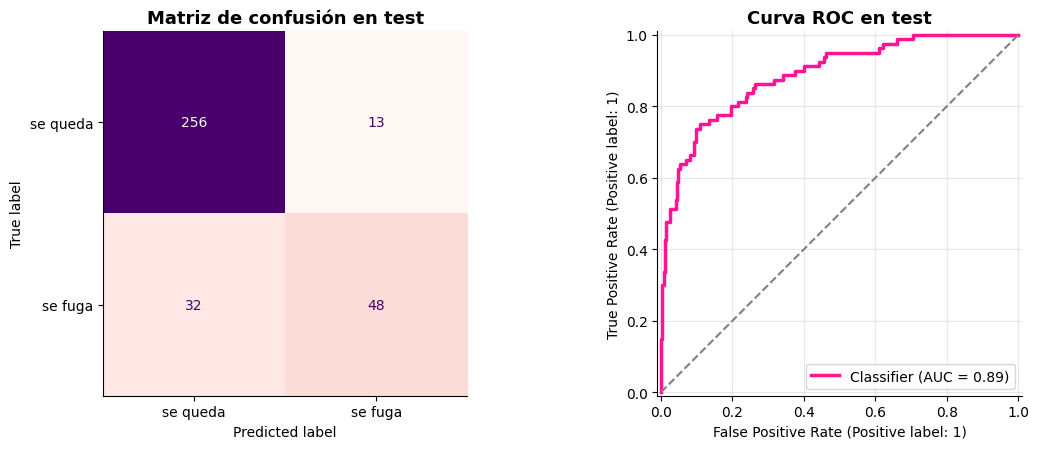

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['se queda', 'se fuga']).plot(
    ax=axes[0], colorbar=False, cmap='RdPu')
axes[0].set_title('Matriz de confusión en test')
axes[0].grid(False)

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=YERA[0], linewidth=2.5)
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('Curva ROC en test')

plt.tight_layout()
plt.show()


<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">💼 Cómo leer esta matriz con ojos de negocio</b><br>
Cada <b>falso negativo</b> es un cliente que se fugó sin que lo llamáramos, pérdida directa. Cada <b>falso positivo</b> es una reclamo de retención a alguien que se iba a quedar, cuesta minutos de call center y quizá un descuento innecesario. Como retener cuesta mucho menos que readquirir, en churn solemos tolerar más falsos positivos a cambio de subir el recall. Si el negocio quisiera aún más recall, bajaríamos el umbral de 0.5 y lo diríamos explícito en el informe.
</div>


<div style="background:#FFF5F8;border:2px solid #1B2A5B;padding:14px 18px;border-radius:12px;">🔮 <b>Predice antes de ejecutar,</b> saquemos la probabilidad de fuga de UN cliente del test y comparémosla con el veredicto seco</div>


In [16]:
cliente_x = X_test.iloc[[0]]
proba_x = pipe_final.predict_proba(cliente_x)[0, 1]
pred_x = int(pipe_final.predict(cliente_x)[0])
print(f"Cliente de prueba → probabilidad de fuga {proba_x:.0%} · veredicto con umbral 0.5, {'SE FUGA 🚨' if pred_x else 'se queda ✅'}")

Cliente de prueba → probabilidad de fuga 8% · veredicto con umbral 0.5, se queda ✅


<div style="background:#FFF5F8;border:2px solid #E0218A;padding:14px 18px;border-radius:12px;">🤔 <b>Los porqués de esta celda,</b> el veredicto seco esconde el matiz, un cliente de 45% y uno de 5% reciben el mismo se queda con el umbral default. En la siguiente sección la perilla del umbral rescata ese matiz y lo convierte en soles.</div>


## 7b. Ajuste del umbral, la decisión es del negocio

El umbral por defecto de 0.5 no es una ley, es una convención. Nuestro criterio de éxito pedía recall de fuga por encima de 0.70, así que movemos el umbral hasta cumplirlo y medimos cuánta precision pagamos a cambio.

In [17]:
from sklearn.metrics import precision_score, recall_score

umbrales = np.arange(0.15, 0.61, 0.05)
tabla = []
for u in umbrales:
    y_u = (y_proba >= u).astype(int)
    tabla.append({'umbral': round(u, 2),
                  'recall_fuga': round(recall_score(y_test, y_u), 3),
                  'precision_fuga': round(precision_score(y_test, y_u), 3)})
tabla = pd.DataFrame(tabla)
print(tabla.to_string(index=False))

# Elegimos el umbral más alto que cumple recall >= 0.70
umbral_negocio = tabla.loc[tabla['recall_fuga'] >= 0.70, 'umbral'].max()
print()
print('Umbral elegido para el negocio,', umbral_negocio)

y_pred_negocio = (y_proba >= umbral_negocio).astype(int)
print()
print(classification_report(y_test, y_pred_negocio, target_names=['se queda', 'se fuga']))

 umbral  recall_fuga  precision_fuga
   0.15        0.863           0.489
   0.20        0.800           0.538
   0.25        0.775           0.585
   0.30        0.750           0.667
   0.35        0.738           0.694
   0.40        0.700           0.683
   0.45        0.650           0.712
   0.50        0.600           0.787
   0.55        0.537           0.782
   0.60        0.512           0.837

Umbral elegido para el negocio, 0.4

              precision    recall  f1-score   support

    se queda       0.91      0.90      0.91       269
     se fuga       0.68      0.70      0.69        80

    accuracy                           0.86       349
   macro avg       0.80      0.80      0.80       349
weighted avg       0.86      0.86      0.86       349



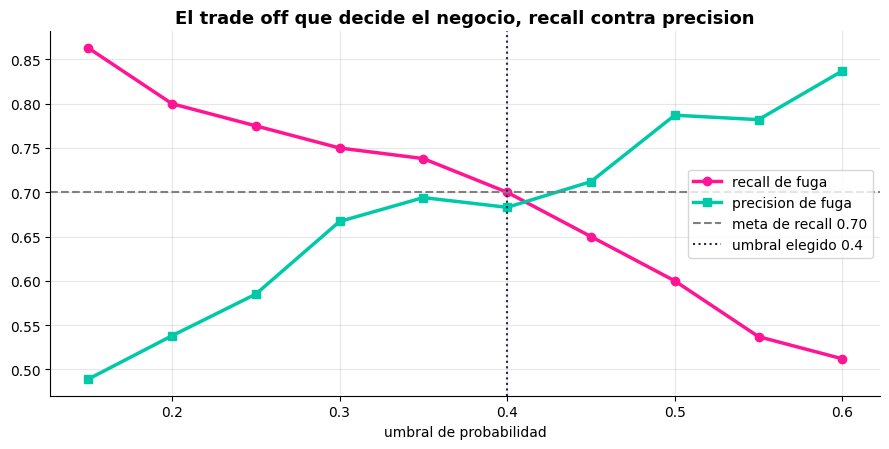

In [18]:
plt.figure(figsize=(9, 4.6))
plt.plot(tabla['umbral'], tabla['recall_fuga'], marker='o', linewidth=2.5,
         color=YERA[0], label='recall de fuga')
plt.plot(tabla['umbral'], tabla['precision_fuga'], marker='s', linewidth=2.5,
         color=YERA[3], label='precision de fuga')
plt.axhline(0.70, linestyle='--', color='gray', label='meta de recall 0.70')
plt.axvline(umbral_negocio, linestyle=':', color=YERA[5], label=f'umbral elegido {umbral_negocio}')
plt.title('El trade off que decide el negocio, recall contra precision')
plt.xlabel('umbral de probabilidad')
plt.legend()
plt.tight_layout()
plt.show()


<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">💎 Lo que acabamos de hacer es oro en una entrevista</b><br>
No cambiamos el modelo, cambiamos la regla de decisión. Con el umbral ajustado capturamos a la mayoría de los clientes que se fugan, aceptando llamar a algunos que se iban a quedar. Como una reclamo de retención cuesta centavos comparada con perder al cliente, el negocio gana. Saber explicar esto te diferencia de quien solo reporta accuracy.
</div>


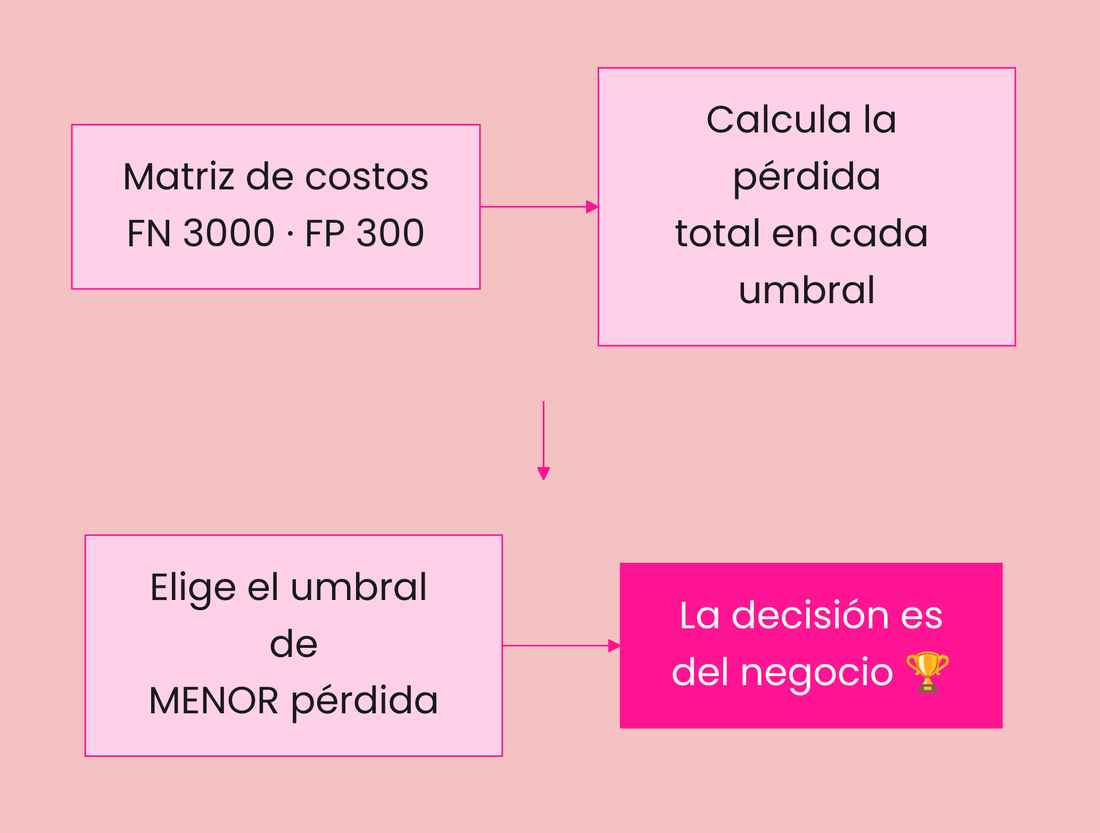

*El umbral no se elige por intuición, se elige donde la pérdida total es mínima.*


In [19]:
#@title 🎬 Toca play · El tablero de costos del CEO, mueve el umbral
import ipywidgets as widgets
import numpy as np

def tablero_costos(umbral=0.35, costo_fuga_perdida=3000, costo_retencion=300):
    y_u = (y_proba >= umbral).astype(int)
    fn = int(((np.array(y_test) == 1) & (y_u == 0)).sum())
    fp = int(((np.array(y_test) == 0) & (y_u == 1)).sum())
    perdida = fn * costo_fuga_perdida + fp * costo_retencion
    print(f"Umbral {umbral:.2f} → {fn} fugas sin alerta (S/ {costo_fuga_perdida} c/u) + {fp} retenciones de más (S/ {costo_retencion} c/u)")
    print(f"Pérdida total para PolliCreditos, S/ {perdida:,}")

widgets.interact(tablero_costos,
                 umbral=widgets.FloatSlider(min=0.10, max=0.80, step=0.05, value=0.35, description="umbral"),
                 costo_fuga_perdida=widgets.IntSlider(min=500, max=6000, step=500, value=3000, description="S/ por fuga"),
                 costo_retencion=widgets.IntSlider(min=50, max=1000, step=50, value=300, description="S/ retención"))

Barre el umbral de 0.10 a 0.80 y encuentra el punto de menor pérdida, luego cambia los costos y mira cómo el umbral óptimo se mueve. La perilla es de negocio, no de matemática. 🐥


## 8. Explicabilidad, abrir la caja del modelo

Un modelo que nadie entiende no se despliega. Usamos dos lentes, permutation importance sobre el pipeline completo y SHAP sobre el modelo final.

### 🧮 La matemática detrás · Esperanza matemática, el corazón de SHAP

$\phi_i = E[f(X) \mid x_i] - E[f(X)]$

**Lectura en palabras,** el valor SHAP de una variable es cuánto mueve la predicción respecto al promedio, un promedio ponderado de contribuciones, teoría de juegos aplicada.

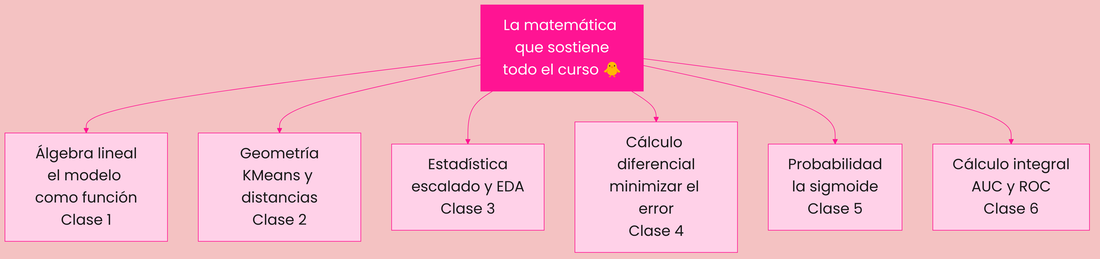

<div style="background:#FFF5F8;border:2px solid #E0218A;padding:14px 18px;border-radius:12px;">🤔 <b>Por qué te sirve saberlo,</b> Y con esto cierras el mapa, cada clase del curso se apoyó en una rama de la matemática que ya conocías del colegio o la universidad.<br><br>🐥 No necesitas dominar esto hoy, necesitas saber que existe y a qué puerta tocar cuando quieras profundizar.</div>


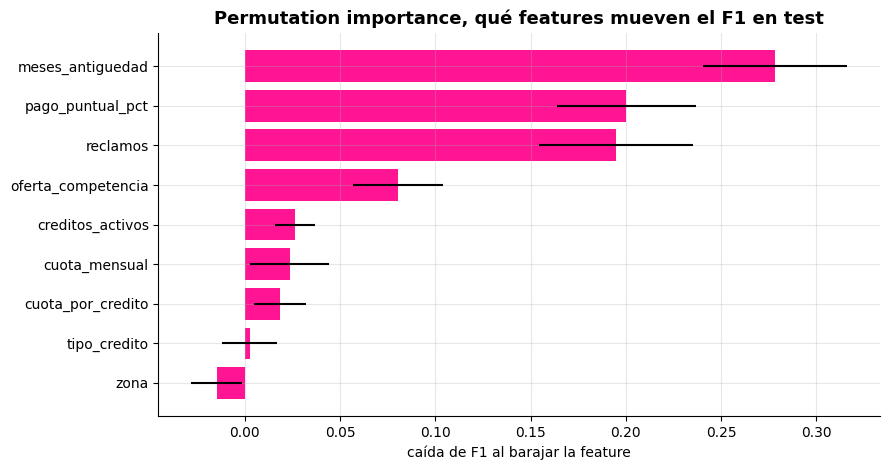

In [20]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(pipe_final, X_test, y_test, n_repeats=15,
                              random_state=42, scoring='f1')
orden = perm.importances_mean.argsort()

plt.figure(figsize=(9, 4.8))
plt.barh(np.array(X.columns)[orden], perm.importances_mean[orden],
         xerr=perm.importances_std[orden], color=YERA[0])
plt.title('Permutation importance, qué features mueven el F1 en test')
plt.xlabel('caída de F1 al barajar la feature')
plt.tight_layout()
plt.show()


<div style="background: #FFF5F8; border: 2px dashed #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#1B2A5B; font-size: 16px;">📖 Concepto nuevo, <span style="color:#FF1493;">SHAP</span></b><br>
Técnica basada en teoría de juegos que reparte la predicción de cada cliente entre sus features, diciendo cuánto empujó cada una hacia fuga o hacia permanencia.<br>
<i>🐥 En idioma pollito, es repartir la cuenta de una pollada entre amigos según lo que comió cada uno, a cada feature le toca su parte justa de la predicción.</i>
</div>


Background dataset has 250 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=250 when initializing the masker.


/tmp/ipykernel_621/875804751.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(vals, muestra, feature_names=nombres_feat, show=False,


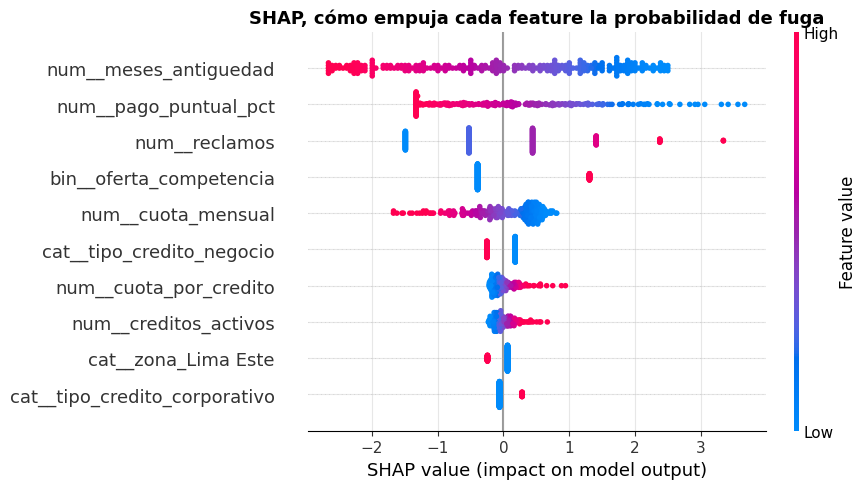

In [21]:
import shap

# Transformamos el test con el preprocesador ya ajustado y explicamos el modelo final
X_test_prep = pipe_final.named_steps['prep'].transform(X_test)
nombres_feat = pipe_final.named_steps['prep'].get_feature_names_out()
modelo_final = pipe_final.named_steps['modelo']

muestra = X_test_prep[:250]
if hasattr(muestra, 'toarray'):
    muestra = muestra.toarray()

# shap.Explainer detecta solo el tipo de modelo, sirve para lineales y para árboles
explainer = shap.Explainer(modelo_final, muestra)
sv = explainer(muestra)
vals = sv.values
if vals.ndim == 3:            # modelos que devuelven una salida por clase
    vals = vals[:, :, 1]      # nos quedamos con la clase fuga

shap.summary_plot(vals, muestra, feature_names=nombres_feat, show=False,
                  plot_size=(9, 5), max_display=10)
plt.title('SHAP, cómo empuja cada feature la probabilidad de fuga')
plt.tight_layout()
plt.show()


<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🔦 Lectura de la explicabilidad</b><br>
Ambos lentes cuentan la misma historia, las reclamos, la puntualidad de pago, la antigüedad y la oferta de la competencia dominan la predicción. La zona casi no aporta, excelente noticia frente al riesgo de sesgo geográfico que anotamos en la gobernanza. Cuando la importancia y el conocimiento del negocio coinciden, el modelo gana credibilidad frente a gerencia.
</div>


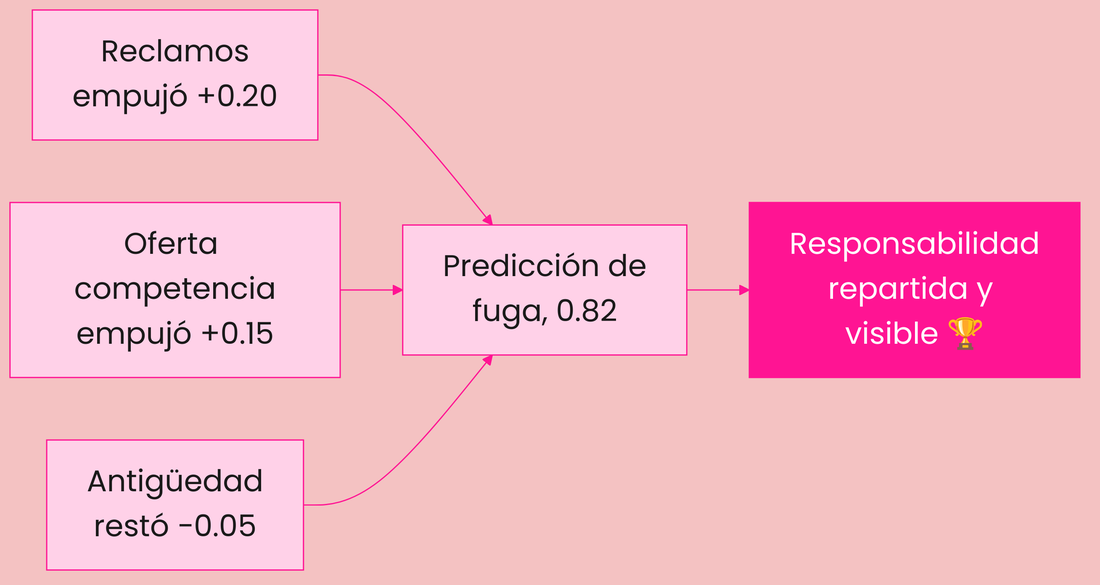

*SHAP reparte la responsabilidad de cada predicción entre las variables, con firma y monto.*


### ✍️ Práctica rápida, lee el SHAP

Responde tú primero, y recién ahí toca para comparar.

<details style="background:#FFF5F8;border-radius:10px;padding:10px 14px;margin:8px 0;"><summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">En un cliente, reclamos empujó +0.20 hacia la fuga y antigüedad restó −0.05, ¿qué le dices al equipo de retención?</summary><p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">Que la llamada ataque los reclamos pendientes primero, es el empujón más grande de SU predicción, la antigüedad juega a favor y no se toca</p></details><details style="background:#FFF5F8;border-radius:10px;padding:10px 14px;margin:8px 0;"><summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">¿SHAP demuestra que resolver los reclamos REDUCE la fuga?</summary><p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">No, SHAP explica qué usó el modelo para predecir, es asociación, afirmar el efecto de intervenir requiere análisis causal aparte</p></details>


## 9. Chequeo de equidad por zona

Cerramos el riesgo que abrimos al inicio, ¿el modelo se equivoca parecido en todas las zonas?

In [22]:
from sklearn.metrics import recall_score

chequeo = X_test.copy()
chequeo['real'] = y_test.values
chequeo['pred'] = y_pred_negocio  # usamos la regla de decisión final del negocio

filas = []
for z, grupo in chequeo.groupby('zona'):
    if grupo['real'].sum() > 0:
        filas.append({'zona': z, 'clientes': len(grupo),
                      'recall_fuga': round(recall_score(grupo['real'], grupo['pred']), 3)})
pd.DataFrame(filas).sort_values('recall_fuga', ascending=False)

,zona,clientes,recall_fuga
0,Callao,78,0.778
4,Lima Sur,68,0.750
3,Lima Norte,65,0.727
1,Lima Centro,70,0.714
2,Lima Este,68,0.571



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">⚖️ Veredicto de equidad</b><br>
Los recalls por zona se mueven en un rango razonable y sin un patrón que castigue sistemáticamente a una zona. Si una zona mostrara un recall muy inferior, tocaría investigar antes de desplegar, por ejemplo revisar si sus datos tienen más nulos o menos historia. Este chequeo toma cinco minutos y evita titulares feos.
</div>


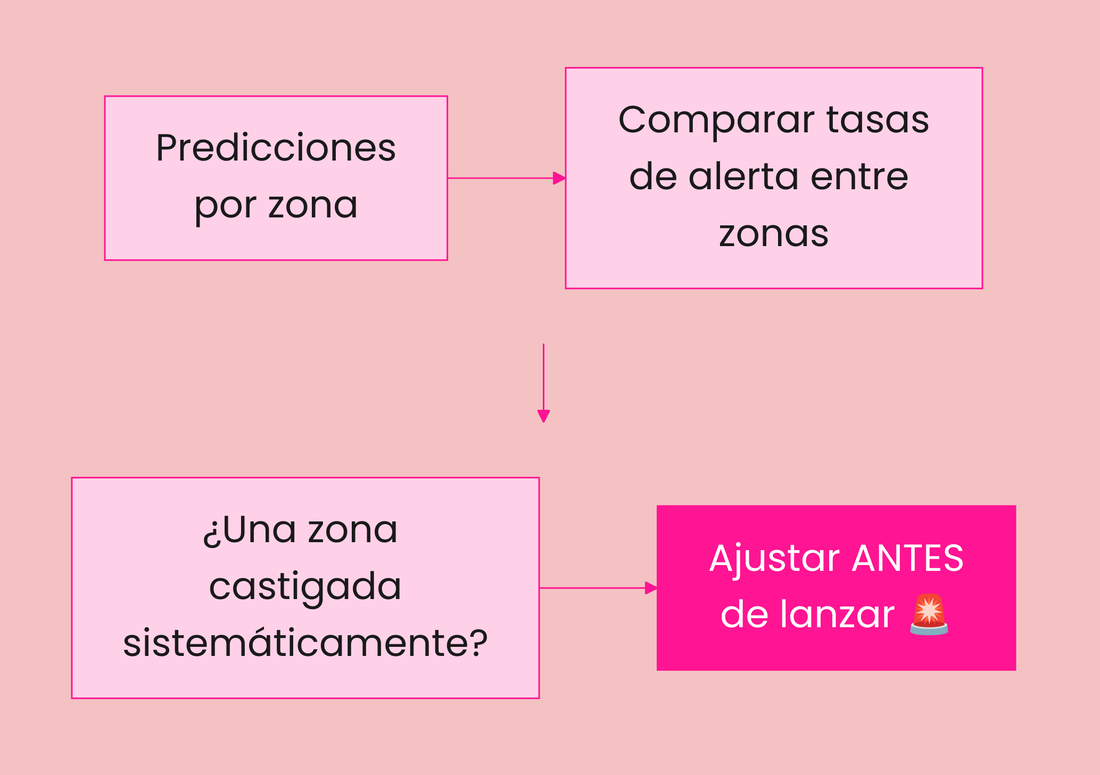

*El chequeo de equidad en cuatro pasos, y se corre antes de lanzar, no después del escándalo.*


## 10. Conclusiones de negocio

El entregable final nunca es un F1, es una recomendación que el gerente entienda en dos minutos.

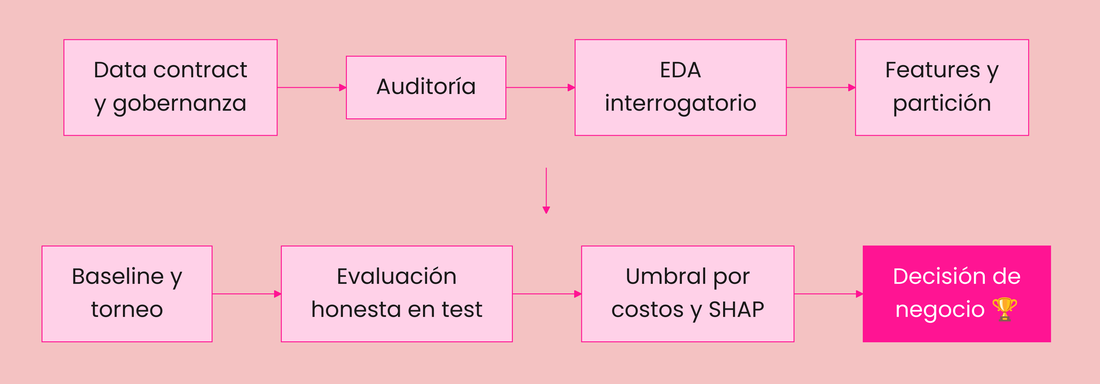

*Mira todo lo que recorriste, esto es exactamente lo que entrega una data scientist senior.*



<div style="background: #FFF5F8; border:2px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">📊 Informe ejecutivo para PolliCreditos</b><br>
<ul><li>El modelo identifica a la mayoría de los clientes que van a fugar el próximo mes, superando con claridad al baseline y con un AUC sólido.</li><li>Las señales de alerta más fuertes son accionables, cliente que llama repetidas veces a reclamos, que empieza a pagar tarde, que tiene poca antigüedad o que recibió oferta de la competencia.</li><li>Recomendación, correr el modelo cada cierre de mes, priorizar la lista por probabilidad de fuga y darle al call center las tres razones principales de cada cliente usando SHAP.</li><li>El modelo no depende de la zona geográfica y el chequeo de equidad salió limpio, se puede desplegar con monitoreo mensual de sus métricas.</li><li>Próximo paso sugerido, un piloto A/B, mitad de los clientes en riesgo recibe la oferta de retención y la otra mitad no, para medir el impacto real en soles.</li></ul>
</div>


<div style="background:#FFF5F8;border:2px solid #1B2A5B;padding:12px 18px;border-radius:12px;"><b style="color:#1B2A5B;">📚 Para profundizar cuando termines la clase</b><ul style="margin:6px 0 0;"><li style="margin:4px 0;"><a href="https://shap.readthedocs.io">Documentación oficial de SHAP</a>, la caja de herramientas completa de explicabilidad</li><li style="margin:4px 0;"><a href="https://scikit-learn.org/stable/modules/compose.html">Pipelines en scikit-learn</a>, la ficha oficial de las tuberías sin fuga</li><li style="margin:4px 0;"><a href="https://fairlearn.org">Fairlearn, equidad en ML</a>, el siguiente nivel del chequeo de equidad que hiciste hoy</li></ul></div>


## 11. Reproducibilidad

Para correr este proyecto en cualquier máquina basta este <code>requirements.txt</code>:

```
numpy
pandas
matplotlib
scikit-learn
shap
```

Y la estructura de carpetas que vimos en el curso de Python:

```
proyecto_churn/
├── datos/
├── notebooks/
│   └── proyecto_churn.ipynb
├── src/
├── requirements.txt
└── README.md
```



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 18px;">🎮 Trivia pollito, versión resuelta</b><br><br>
<b>1. ¿Por qué la imputación de nulos va dentro del pipeline y no antes del split?</b><ol type='a'><li>Porque es más rápido</li>
<li>✅ <b>Para que aprenda sus parámetros solo del train y no haya fuga de información</b></li>
<li>Porque scikit-learn no acepta nulos en ningún caso</li>
<li>Por estética del código</li></ol><i>💡 Si la mediana se calcula con todo el dataset, el test contaminó el entrenamiento. El pipeline garantiza fit solo en train.</i><br>
<b>2. El baseline de mayoría sirve para</b><ol type='a'><li>Ganar el torneo de modelos</li>
<li>✅ <b>Tener un piso honesto que cualquier modelo útil debe superar</b></li>
<li>Imputar valores faltantes</li>
<li>Reducir el overfitting</li></ol><i>💡 Con clases desbalanceadas el baseline revela cuánta accuracy es gratis, y obliga a mirar métricas por clase.</i><br>
<b>3. En churn, tolerar más falsos positivos suele aceptarse porque</b><ol type='a'><li>Los falsos positivos no cuestan nada</li>
<li>✅ <b>Retener con una reclamo cuesta mucho menos que perder al cliente y readquirir otro</b></li>
<li>El recall no importa en negocio</li>
<li>La matriz de confusión lo exige</li></ol><i>💡 Es una decisión económica, el costo asimétrico de los errores define el umbral, no la estadística sola.</i><br>
<b>4. SHAP nos dice</b><ol type='a'><li>Qué modelo elegir automáticamente</li>
<li>✅ <b>Cuánto empujó cada feature la predicción de cada cliente individual</b></li>
<li>Si el dataset tiene duplicados</li>
<li>El tamaño ideal del test</li></ol><i>💡 Es explicabilidad a nivel individual, perfecta para darle argumentos concretos al call center en cada reclamo.</i><br>
</div>



<div style="background: linear-gradient(135deg, #FF1493, #FF69B4); border-radius: 18px; padding: 28px 30px; color: white;">
<b style="font-size: 20px;">🏁 Recap de la clase</b>
<ul><li>Un proyecto serio arranca con definición del problema, data contract y riesgos, no con el modelo</li>
<li>La limpieza se documenta y la imputación vive dentro del pipeline para evitar fuga de información</li>
<li>El EDA es un interrogatorio con hallazgos escritos, no una galería de gráficos</li>
<li>Baseline primero, después el torneo con validación cruzada y una sola evaluación final en test</li>
<li>Permutation importance y SHAP abren la caja del modelo y el chequeo de equidad cierra los riesgos</li>
<li>El entregable final es una recomendación de negocio, en este caso una lista priorizada para retención</li></ul>
<b>📝 Tarea de la semana,</b> replica este proyecto completo con otro problema, por ejemplo predecir qué alumnos abandonan un curso online. Escribe tu propio data contract, tus riesgos y tus conclusiones de negocio. Ese notebook es oro puro para tu portafolio y para tu CV, que de paso puedes analizar gratis en misscv.com.
<br><br>
<div style="background: rgba(255,255,255,.16); border-radius: 12px; padding: 12px 18px; font-size: 14px;">
🐥 ¿Quieres seguir creciendo? En <b>missyera.com</b> encuentras mis cursos y consultoría de IA, y en <b>misscv.com</b> analizas tu CV gratis con inteligencia artificial.<br><br>
<b>Chau, chau. Bye, bye. 💋</b> · © 2026 Yera Flores · @soymissyera
</div>
</div>


## 🕵️ La trampa de la Miss

En la clase apareció una versión de este código que se ve inocente. Míralo bien, hay un error que en PolliCreditos costaría plata de verdad. ¿Lo encuentras?

```python
df = df.drop(columns=['zona'])  # no aporta al modelo, fuera
```

<details style="background:#FFF5F8;border-radius:10px;padding:12px 16px;">
<summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">Toca aquí SOLO cuando tengas tu respuesta</summary>
<p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">La zona se botó antes del chequeo de equidad, así que nadie puede auditar si el modelo castiga a una zona. Que una variable sensible no entre al modelo no significa ignorarla, se necesita para verificar la equidad de las predicciones.</p>
</details>

Cuéntame en los comentarios del video si la cazaste a la primera. 🐥


In [23]:
#@title 🎬 Toca play · Quiz de salida, asegura lo de hoy
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de salida, asegura lo de hoy</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. ¿Qué va PRIMERO en un proyecto de nivel senior?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_0" value="0"> Entrenar XGBoost</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_0" value="1"> El data contract y la gobernanza de los datos</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_0" value="2"> El gráfico de barras</label><div id="qout7_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Para qué sirvió el baseline en el torneo?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_1" value="0"> Para adornar la tabla</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_1" value="1"> Para saber si los modelos reales aportan sobre lo trivial</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_1" value="2"> Para ganar el torneo</label><div id="qout7_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">3. El chequeo de equidad por zona verifica que...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_2" value="0"> El modelo corra rápido en todas las zonas</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_2" value="1"> El modelo no castigue sistemáticamente a los clientes de una zona</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout7_2" value="2"> Todas las zonas tengan la misma mora</label><div id="qout7_2_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "lo primero no es el modelo"], [1, "si no le ganas al baseline con claridad, algo anda mal"], [1, "IA responsable con sustancia, no de adorno"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qout7_"+i+"\']:checked");
        var fb=document.getElementById("qout7_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

In [24]:
#@title 🎬 Toca play · ¡Celebra lo que lograste hoy!
from IPython.display import HTML
import random
piezas = "".join(
    f'<div style="position:absolute;left:{random.randint(0,96)}%;top:-10%;font-size:{random.randint(16,30)}px;'
    f'animation:caer {random.uniform(2.4,4.2):.1f}s linear {random.uniform(0,1.6):.1f}s infinite;">'
    f'{random.choice(["🐥","🎉","💖","⭐","🎊"])}</div>' for _ in range(34))
HTML(f"""<div style="position:relative;height:230px;overflow:hidden;background:#FFF5F8;border-radius:16px;border:3px solid #E0218A;">
<style>@keyframes caer {{ to {{ transform: translateY(260px) rotate(360deg); }} }}</style>{piezas}
<div style="position:relative;text-align:center;padding-top:85px;">
<h2 style="color:#E0218A;margin:0;">¡Lo lograste, pollito! 🎓</h2>
<p style="color:#1B2A5B;">Completaste la clase. Respira, celebra y sigue.</p></div></div>""")

## 📖 El glosario que te llevas hoy

| Término | En palabras del curso |
|---|---|
| **Data contract** | la tabla que documenta cada columna, tipo, origen, dueño y calidad esperada, antes de modelar |
| **Baseline** | el modelo tonto de referencia, si tu modelo no le gana con claridad, algo anda mal |
| **SHAP** | la técnica que abre la caja del modelo y muestra qué variables empujan cada predicción |
| **Fairness** | verificar que el modelo no castigue sistemáticamente a un grupo, en este caso por zona |
| **Umbral por costos** | elegir el punto de corte con la matriz de costos del negocio, no con el 0.5 por defecto |
| **Reproducibilidad** | semillas fijas y versiones documentadas para que cualquiera obtenga lo mismo |

Con esta clase el diccionario del curso queda completo. Es tuyo, pollito.


## 🛤️ Tu ruta después de hoy

<div style="background:#FFF5F8;border:2px solid #E0218A;padding:14px 18px;border-radius:12px;"><b style='color:#1B2A5B;'>Tu misión de la semana,</b> re-ejecuta este notebook de arriba a abajo prediciendo cada celda antes de correrla, y completa el reto de la versión estudiantes en el repositorio.</div>

Terminaste el curso completo, de la introducción al proyecto final de churn. Lo que sigue es practicar con tus propios datos.

El reto de esta clase vive en la carpeta `clases/` del repositorio del curso, y su solución se publica una semana después del video. Intenta primero, ahí está el aprendizaje.

Si quieres llevar esto al siguiente nivel, en [missyera.com](https://missyera.com) están el Full Day de IA y los cursos completos, y en [misscv.com](https://misscv.com) puedes analizar tu CV gratis con IA.

**Chau, chau. Bye, bye. 💋**

<sub>© 2026 Yera Flores (Miss Yera) · missyera.com · @soymissyera</sub>


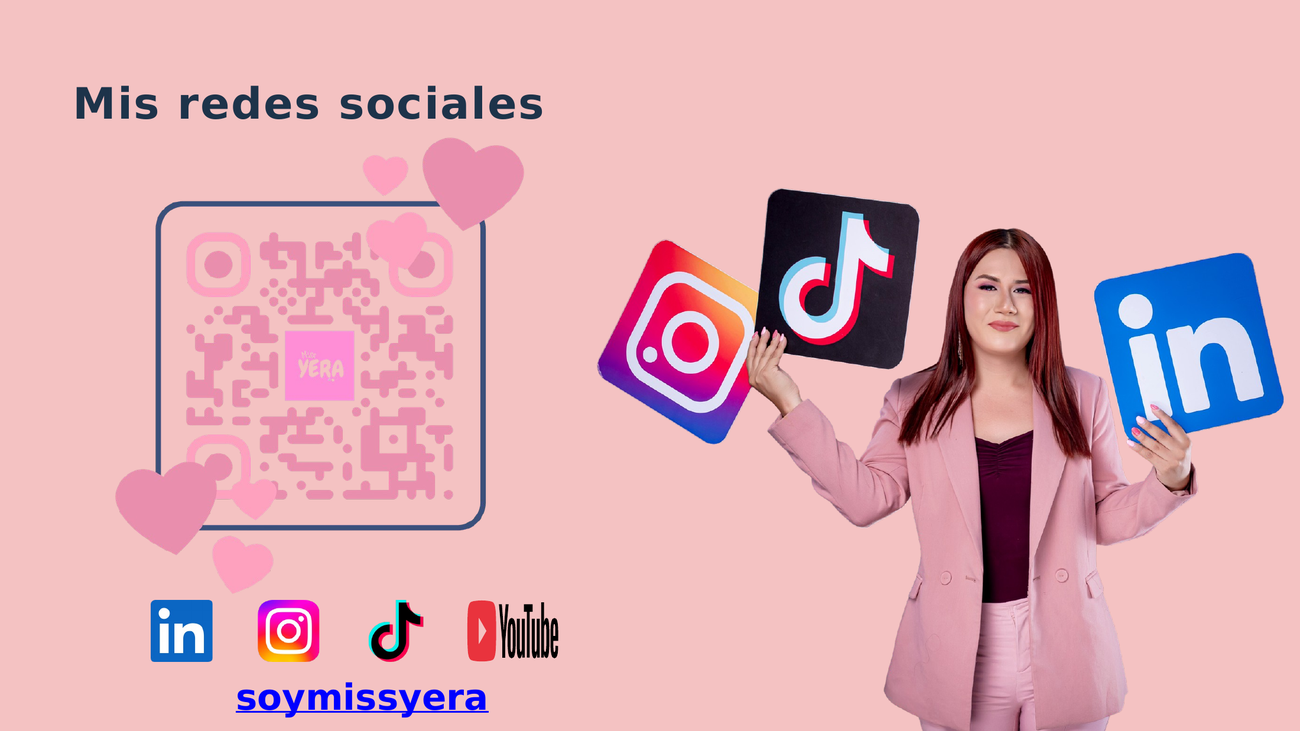
